In [154]:
from keras.datasets import fashion_mnist
# load dataset
(train_X, train_y), (test_X, test_y) = fashion_mnist.load_data()

<h1>Fashion MNIST</h1>

Zalando à mis à disposition est un ensemble de données d'images d'articles, composé 60 000 exemples. 

Chaque exemple est une image en niveaux de gris 28x28.

![](https://miro.medium.com/max/1400/1*RNBs0OsymwAzDyYMk3_0Aw.jpeg)



## Préambule : les données

Les données sont disponible : https://github.com/zalandoresearch/fashion-mnist

Il est possible de directement importer les datas sous Keras comme ceci.

## Partie 1 - Analyse des données

* Compter le nombre de classes et le nombre d'images par classe.
* Importer les images (avec leur classe), on pourra au choix garder des tableaux 28x28 ou 784 (x1).
* Représenter les 10 premières images avec leur nom de classe en titre.

In [75]:
train_X.shape #les dimensions de notre train data 


(60000, 28, 28)

In [155]:
import numpy as np
classes_uniques = np.unique(train_y)
nombre_de_classes = len(classes_uniques)
nombre_de_classes #les classes de 0 à 9 (donc 10 classes différentes)
#classes_uniques

10

In [156]:
#J'ai eu un problème de type ,et doncje change le type et je normalise pour avoir
#des valeurs entre [0,1] ,
train_X = train_X.astype('float32') / 255.0
test_X= test_X.astype('float32') / 255.0
train_X.shape
print("train_X :", train_X.min(), train_X.max())   # doit afficher 0.0 1.0
print("test_X  :", test_X.min(),  test_X.max())

train_X : 0.0 1.0
test_X  : 0.0 1.0


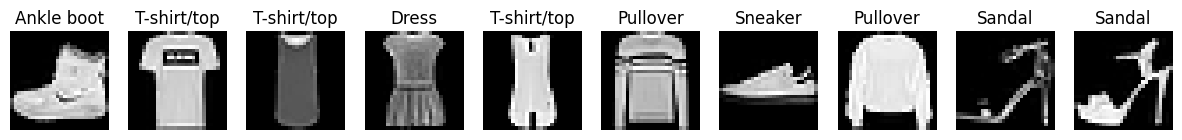

In [127]:
import matplotlib.pyplot as plt
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# On prépare la figure
plt.figure(figsize=(15, 4))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    
    # On affiche l'image
    plt.imshow(train_X[i], cmap='gray')
    
    # On récupère le chiffre dans trainy[i] (ex: 9) 
    # et on cherche le nom correspondant dans notre liste (ex: class_names[9])
    index_classe = train_y[i]
    plt.title(class_names[index_classe])
    
    plt.axis('off') # Pour enlever les axes X et Y car on veut que les images

plt.show()

   
**Conseil : mettez au point votre code avec par exemple seulement 1000 images et en dernier lieu avec la totalité**

In [128]:
#on réduit nos données pour amélioré la rapidité de l'execution
trainX=train_X[:10000]
trainy=train_y[:10000]
testX=test_X[:10000]
testy=test_y[:10000]
train_X.shape

(60000, 28, 28)

## Partie 2 - Classification par Réseau Dense

* Proposer une modèle avec 2 couches cachées (éviter le sur-apprentissage !)
* Tracer les courbes d'évolution de la fonction Loss ainsi que de l'accuracy du modèle lors des itérations.
* Afficher ou tracer la matrice de confusion obtenue.
* Représenter tout (ou partie si >10) des cas de mauvaise prédiction, avec classe prédite et classe exacte en titre.

In [129]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten,Input

X_train_flat = train_X.reshape(-1, 784)
X_test_flat = test_X.reshape(-1, 784)

model_dense = Sequential([
    #couche d'entrer
    Input(shape=(784,)), 
    
    # couches cachées
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.4),


    
    
    # Couche de sortie
    Dense(10, activation='softmax')
])

model_dense.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

In [115]:
X_train_flat.shape

(60000, 784)

In [130]:
history = model_dense.fit(X_train_flat, train_y, 
                    epochs=20, 
                    batch_size=32, 
                    validation_split=0.2)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.6700 - loss: 0.9167 - val_accuracy: 0.8292 - val_loss: 0.4557
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8165 - loss: 0.5066 - val_accuracy: 0.8517 - val_loss: 0.4015
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8340 - loss: 0.4652 - val_accuracy: 0.8620 - val_loss: 0.3754
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8436 - loss: 0.4342 - val_accuracy: 0.8628 - val_loss: 0.3695
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8475 - loss: 0.4204 - val_accuracy: 0.8698 - val_loss: 0.3548
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8531 - loss: 0.4081 - val_accuracy: 0.8627 - val_loss: 0.3629
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8543 - loss: 0.4006 - val_accuracy: 0.8712 - val_loss: 0.3496
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8548 - loss: 

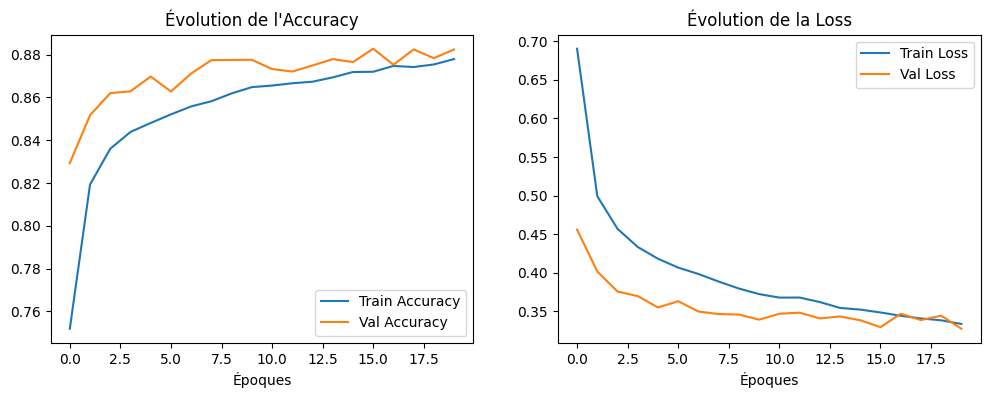

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Graphique de l'Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Évolution de l\'Accuracy')
plt.xlabel('Époques')
plt.legend()

# Graphique de la Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Évolution de la Loss')
plt.xlabel('Époques')
plt.legend()

plt.show()

- L'utilisation d'un réseau de neurones Dense (Multi-Layer Perceptron), optimisé par l'ajout de couches de Dropout, a permis de régulariser efficacement l'apprentissage. En désactivant aléatoirement une fraction des neurones à chaque itération, nous avons forcé le réseau à apprendre des représentations plus robustes, neutralisant ainsi le surapprentissage observé lors des premiers essais.
- Comme illustré par les graphiques, la convergence est saine,la fonction loss de validation suit étroitement celle de l'entraînement sans diverger. Le modèle atteint une précision de 87% sur les données de validation, ce qui démontre une solide capacité de généralisation pour une architecture entièrement connectée, tout en maintenant une cohérence totale entre les performances d'apprentissage et de test.

## Matrice de confusion explication

![image.png](https://cdn.prod.website-files.com/660ef16a9e0687d9cc27474a/662c42677529a0f4e97e4f96_644aea65cefe35380f198a5a_class_guide_cm08.png)



Dans une matrice de confusion, nous classons les résultats selon quatre catégories fondamentales :

- Vrais Positifs (True Positives) : La valeur réelle est positive, et le modèle l'a correctement classée comme positive.

- Faux Négatifs (False Negatives) : La valeur réelle est positive, mais le modèle l'a classée par erreur comme négative.

- Faux Positifs (False Positives) : La valeur réelle est négative, mais le modèle l'a classée par erreur comme positive.

- Vrais Négatifs (True Negatives) : La valeur réelle est négative, et le modèle l'a correctement classée comme négative.

**La matrice de confusion offre une vue d'ensemble complète qui permet de mesurer réellement la performance d'un modèle. Contrairement à un simple score de précision globale, elle permet d'identifier précisément le type d'erreurs commises par notre réseau de neuronnes.**


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


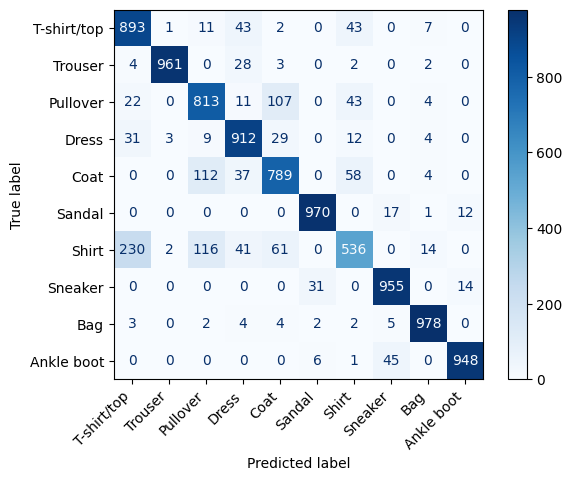

In [152]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# test_X = test_X / 255.0
y_prediction=model_dense.predict(X_test_flat)
# On récupère l'indice de la probabilité maximale pour chaque ligne (axis=1)
# Cela transforme le (60000, 10) en (60000,)
# X_test_flat.shape
#un problème de type rencontré donc pour test_y
# test_y=test
y_prediction = y_prediction.argmax(axis=1)
# print("y_prediction: ", y_prediction.shape, y_prediction.dtype, y_prediction[:5])
# print("test_y :", test_y.shape, test_y.dtype, test_y[:5])
Matrice_de_confusion=confusion_matrix(test_y,y_prediction)
Matrice_de_confusion

mes_classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
disp = ConfusionMatrixDisplay(confusion_matrix=Matrice_de_confusion, display_labels=mes_classes)
disp.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=45, ha='right')
plt.show()
# print(testy.shape)
# y_prediction.shape
#y_prediction[2]
# print(X_test_flat.shape)
# y_prediction.shape


In [137]:
Matrice_de_confusion[6][6]/1000


0.536

L'analyse de la matrice de confusion révèle que si le modèle identifie parfaitement les silhouettes uniques (Trousers, Bags), il peine sur les similitudes morphologiques (surtout les vetements du hauts qui partage une morphologie similaire). Le cas des Shirts est critique avec seulement **53,6% de réussite ,tandis que les 46,4% d'erreurs se dispersent vers les classes Coat, Pullover et T-shirt, prouvant une confusion sur les caractéristiques du haut du corp**.Pour améliorer ces résultats, nous pouvons se tourner vers une architecture convolutive ou on peut ciblée plus en profondeur les caractéristiques distinctes de chaques catégories(à travers l'encodage ) afin de mieux distinguer ces catégories visuellement proches.

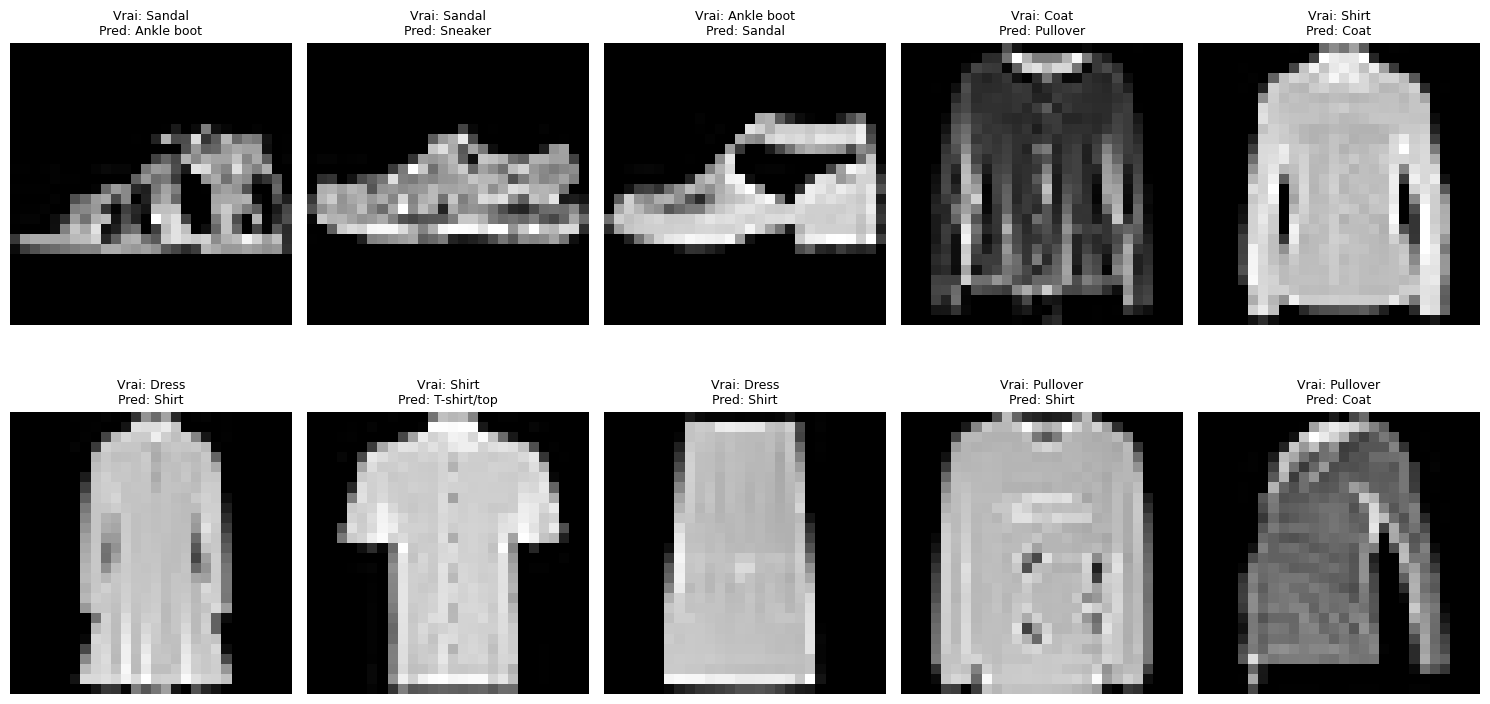

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# On trouve les indices où le modèle s'est trompé
indices_erreurs = np.where(y_prediction != testy)[0]

# On prépare une figure pour afficher les 10 premières erreurs
plt.figure(figsize=(15, 8))

for i, indice in enumerate(indices_erreurs[:10]): # On s'arrête à 10
    plt.subplot(2, 5, i + 1)
    
    # On affiche l'image (X_test doit être au bon format pour l'affichage)
    plt.imshow(X_test_flat[indice].reshape(28, 28), cmap='gray')
    
    # On récupère les noms des classes
    classe_reelle = mes_classes[testy[indice]]
    classe_predite = mes_classes[y_prediction[indice]]
    
    plt.title(f"Vrai: {classe_reelle}\nPred: {classe_predite}", fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

Si la mauvaise qualité des images limite le modèle, elle n'est pas une fatalité. En passant à l'étape d'encodage, l'objectif est de ne plus traiter les pixels comme des valeurs brutes, mais d'extraire des caractéristiques mathématiques plus riches (textures, contours, contrastes). Cet encodage va permettre de mieux séparer les classes qui se ressemblent visuellement, transformant une "bouillie de pixels" en une signature numérique précise que le réseau de neurones pourra enfin distinguer efficacement.

## Partie 3 - Classification par réseau neuronal convolutif (CNN)


* Proposer une modèle dit réseau neuronal convolutif (toujours éviter le sur-apprentissage !)
  Vous pouvez vous inspirer du réseau peoposer par Mr Lecun : LeNet-5
* Tracer les courbes d'évolution de la fonction Loss ainsi que de l'accuracy du modèle lors des itérations.
* Afficher ou tracer la matrice de confusion obtenue.
* Représenter tout (ou partie si >10) des cas de mauvaise prédiction, avec classe prédite et classe exacte en titre.

In [157]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

#Je prends l'ensemble des données 
# train_X = train_X.astype('float32') / 255.0
# test_X  = test_X.astype('float32')  / 255.0 
X_train_cnn = train_X.reshape(-1, 28, 28, 1)
X_test_cnn = test_X.reshape(-1, 28, 28, 1)
model_cnn = Sequential([
    # Entrée : 28x28
    Input(shape=(28, 28, 1)), 
    
    # 28x28 -> convolution -> 26x26 -> pooling -> 13x13
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)), # Changé ici : (2,2) au lieu de (20,2)
    
    # 13x13 -> convolution -> 11x11 -> pooling -> 5x5
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    
    Flatten(),
    
    # Couches denses
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.4),

    
    
    Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
print("train_X :", train_X.min(), train_X.max())
print("test_X  :", test_X.min(),  test_X.max())

train_X : 0.0 1.0
test_X  : 0.0 1.0


In [158]:
history = model_cnn.fit(X_train_cnn, train_y, 
                    epochs=10, 
                    batch_size=32, 
                    validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 28ms/step - accuracy: 0.6510 - loss: 0.9448 - val_accuracy: 0.8538 - val_loss: 0.3983
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.8347 - loss: 0.4626 - val_accuracy: 0.8785 - val_loss: 0.3367
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.8658 - loss: 0.3848 - val_accuracy: 0.8751 - val_loss: 0.3330
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - accuracy: 0.8792 - loss: 0.3475 - val_accuracy: 0.8910 - val_loss: 0.2897
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.8879 - loss: 0.3216 - val_accuracy: 0.8840 - val_loss: 0.3172
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - accuracy: 0.8934 - loss: 0.3012 - val_accuracy: 0.9037 - val_loss: 0.2640
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.9019 - loss: 0.2749 - val_accuracy: 0.8993 - val_loss: 0.2779
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - accuracy: 0.9072 -

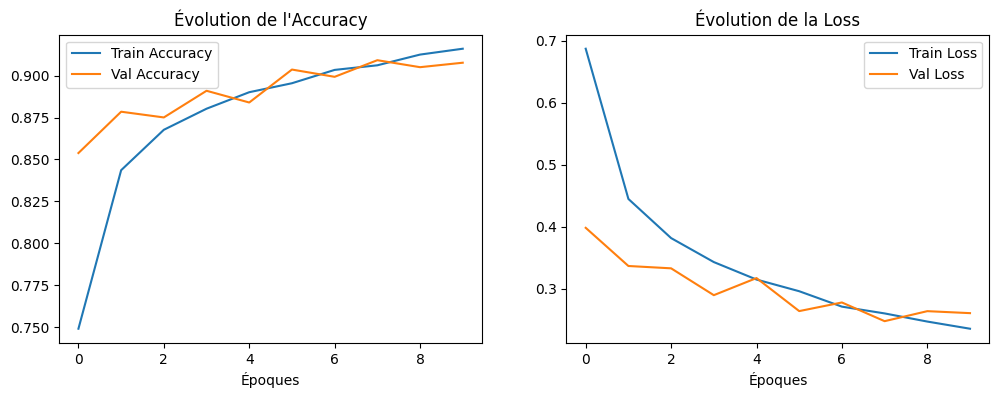

In [159]:

plt.figure(figsize=(12, 4))

# Graphique de l'Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Évolution de l\'Accuracy')
plt.xlabel('Époques')
plt.legend()

# Graphique de la Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Évolution de la Loss')
plt.xlabel('Époques')
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
(10000, 10)


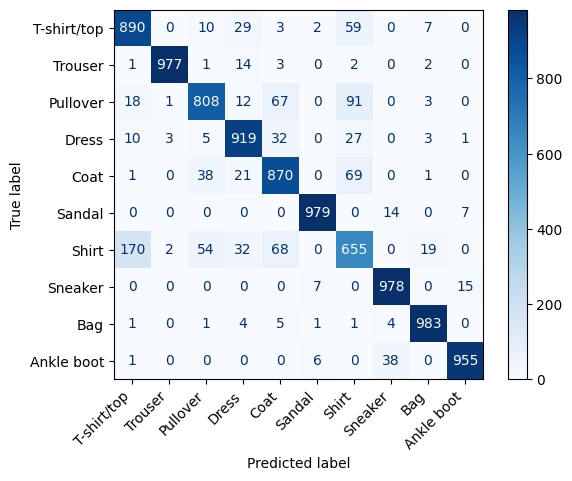

In [163]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_prediction=model_cnn.predict(X_test_cnn)
print(y_prediction.shape)
# On récupère l'indice de la probabilité maximale pour chaque ligne (axis=1)
# Cela transforme le (10000, 10) en (10000,)
y_prediction = y_prediction.argmax(axis=1)
Matrice_de_confusion=confusion_matrix(test_y,y_prediction)
Matrice_de_confusion

mes_classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
disp = ConfusionMatrixDisplay(confusion_matrix=Matrice_de_confusion, display_labels=mes_classes)
disp.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=45, ha='right')
plt.show()
# print(testy.shape)
# y_prediction.shape
#y_prediction[2]
# print(X_test_flat.shape)
# y_prediction.shape


In [161]:
model_cnn.summary()

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 697,952 (2.66 MB)

 Trainable params: 232,650 (908.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 465,302 (1.77 MB)

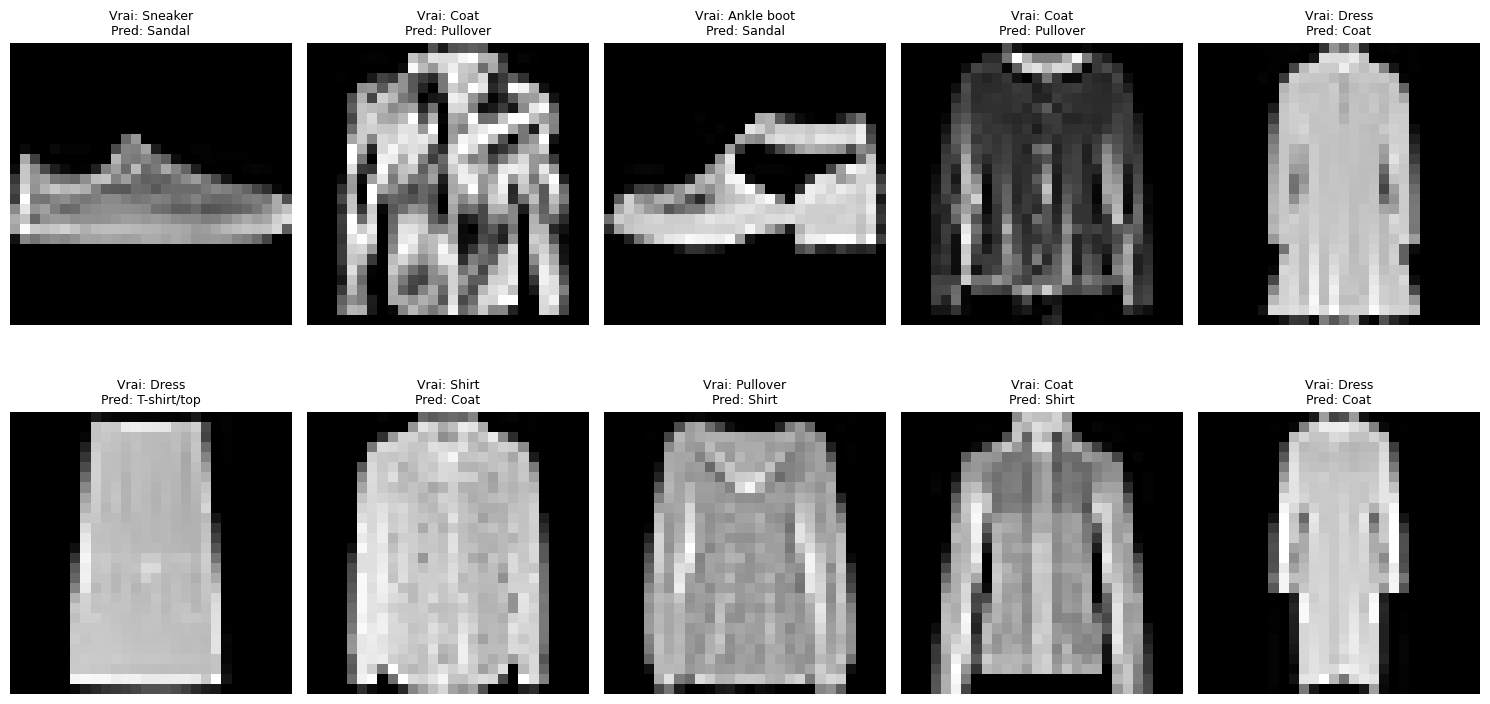

In [164]:
import numpy as np
import matplotlib.pyplot as plt

# On trouve les indices où le modèle s'est trompé
indices_erreurs = np.where(y_prediction != test_y)[0]

# On prépare une figure pour afficher les 10 premières erreurs
plt.figure(figsize=(15, 8))

for i, indice in enumerate(indices_erreurs[:10]): # On s'arrête à 10
    plt.subplot(2, 5, i + 1)
    
    # On affiche l'image (X_test doit être au bon format pour l'affichage)
    plt.imshow(X_test_flat[indice].reshape(28, 28), cmap='gray')
    
    # On récupère les noms des classes
    classe_reelle = mes_classes[testy[indice]]
    classe_predite = mes_classes[y_prediction[indice]]
    
    plt.title(f"Vrai: {classe_reelle}\nPred: {classe_predite}", fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

On peut observer une nette amélioration dans la performance de notre réseau de neurones convolutif qui dépasse la barre des 90% de val accuracy, ce qui se confirme par la matrice de confusion avec une diagonale bien marquée. Les erreurs sur les vêtements du haut (T-shirt, Pullover, Coat) ont diminué par rapport au premier réseau dense de neurones. Il est encore possible d'optimiser et d'affiner notre encodage en agrandissant les matrices de filtres ou en ajoutant davantage de couches, mais il faut faire très attention à ne pas tomber dans le surapprentissage et à maîtriser le nombre de paramètres utilisés.

## Partie 4

Analyser et conclure.

- Ce projet montre que les réseaux de neurones, qu'ils soient denses (MLP) ou convolutifs (CNN), peuvent être des outils très performants pour des tâches de classification d'images. La qualité des données reste cependant un facteur déterminant : ici, les images en 28×28 niveaux de gris offrent une résolution limitée, ce qui plafonne mécaniquement la performance des deux modèles. Cette contrainte se ressent particulièrement sur les classes visuellement proches comme les vêtements du haut, où même un œil humain aurait du mal à trancher.
L'encodage extrait par le CNN, bien que plus riche que celui d'un simple MLP, reste lui aussi dépendant de la qualité des images en entrée. Par ailleurs, le volume de données disponible,bien que conséquent avec 60 000 images ,il pourrait être enrichi pour mieux généraliser, notamment via des techniques de data augmentation (rotations, translations, zooms).
- D'autres pistes d'amélioration sont envisageables :
     - Tester d'autres architectures de filtres,
     - Ajuster les hyperparamètres,
     - Explorer des modèles pré-entraînés via le transfer learning.
- Globalement, ce travail illustre l'une des manipulations possibles des réseaux de neurones dans le cadre de la reconnaissance d'images. Les principes mis en œuvre ici sont directement transposables à d'autres cas d'usage et peuvent contribuer à fluidifier des chaînes de production industrielle, par exemple pour le contrôle qualité automatisé, le tri d'objets, ou la détection de défauts sur des lignes de fabrication.